### Importing the libraries

In [1]:
# data operation libraries
import numpy as np
import pandas as pd

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# for Q-Q plot
import scipy.stats as stats

# as of now, I have imported gerenally used libraries and will import remaining 
# ones as and when needed

### Importing the datasets

In [2]:
train_set = pd.read_csv('../input/titanic/train.csv')
test_set = pd.read_csv('../input/titanic/test.csv')
submission_demo = pd.read_csv('../input/titanic/gender_submission.csv')

### Splitting the sets

In [3]:
x_train = train_set.drop('Survived', axis=1)
y_train = train_set['Survived']
x_test = test_set.copy()
y_test = submission_demo['Survived']

### Data Analysis

In this part I will perform thoroughly and extensive data analysis. Where I will:

1) ***understand the types/nature of the variables*** that we have in our data set: Numerical, categorical and Mixed. Undertanding the nature of the variables will help us decide what feature engineering technique we want to carry on 

2) ***Missing data***

3) **categoriacal Variables**

4) ***Distribution of the variables*** (whether they are skewed. If skewed then how skewed they are)

5) ***Feature Magnitude*** (if we are after building a machine learning model which are sensitive to the feature scale.)

After the data analysis part I will figure out the techniques I want to use on each of our variables.


##### 1) Types of variables

Let's find out what types of variables there are in this dataset

In [4]:
# let's inspect the types of variables in our dataset

x_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

There are mixture of categorical and numerical variables. Numericals are those of type int and float and categorical those of type object.

In [5]:
# we have a variable named PassengerId, which we should not use for prediction

print('Number of Passanger Id labels: ', x_train['PassengerId'].nunique())
print('Number of Passanger observations in the dataset: ', len(x_train))

Number of Passanger Id labels:  891
Number of Passanger observations in the dataset:  891


PassengerId is a unique identifier for each of the passanger. Thus this is not a variable that we can use.

In [6]:
#  make a list of variable types

# numerical: discrete vs. categorical

discrete_variables = [var for var in x_train.columns if x_train[var].dtype != 'O' and var != 'Survived' and x_train[var].nunique() < 10]
continuous_variables = [var for var in x_train.columns if x_train[var].dtype != 'O' and var not in ['Survived','PassengerId'] and var not in discrete_variables]

# mixed

mixed_variables = ['Cabin','Ticket']

# categorical

categorical_variables = [var for var in x_train.columns if x_train[var].dtype == 'O' and var not in mixed_variables]

print('There are {} discrete Variables'.format(len(discrete_variables)))
print('There are {} continuous Variables'.format(len(continuous_variables)))
print('There are {} mixed Variables'. format(len(mixed_variables)))
print('There are {} categorical Variables'. format(len(categorical_variables)))

There are 3 discrete Variables
There are 2 continuous Variables
There are 2 mixed Variables
There are 3 categorical Variables


In [7]:
print(discrete_variables)
print('\n')
print(continuous_variables)
print('\n')
print(mixed_variables)
print('\n')
print(categorical_variables)

['Pclass', 'SibSp', 'Parch']


['Age', 'Fare']


['Cabin', 'Ticket']


['Name', 'Sex', 'Embarked']


##### 2) Missing data

In [8]:
x_train.isnull().mean()

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [9]:
x_test.isnull().mean()

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64

In the variable Age there is 20% of data missing.

There is 77% data missing in the variable cabin, in which the passangers were travelling.

There is 0.2 percent of data missing in the field Emabarked( the port from which passangers boarded the Titanic)

There is only one value missing in the Fare column.

In [10]:
plt.style.use('dark_background')

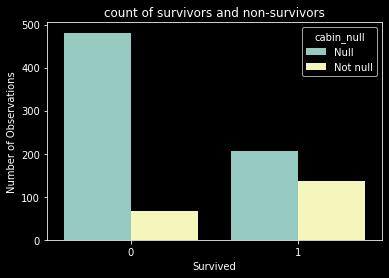

In [11]:
tmp = x_train.copy()

# Let's create a binary variable that indicates 
# if the value of cabin is missing.
tmp['cabin_null'] = np.where(tmp['Cabin'].isnull(), 'Null', 'Not null')

# Let's evaluate the missing values in
# cabin for the people who survived vs the non-survivors.
sns.countplot(x=y_train, hue='cabin_null', data=tmp)
plt.ylabel('Number of Observations')
plt.title('count of survivors and non-survivors')
plt.show()

**Note:** To truly understand whether the data is missing not at random, we need to get extemly familiar with the way data was collected. Analyzing dataset, can only point us in the right direction or help us make assumptions.

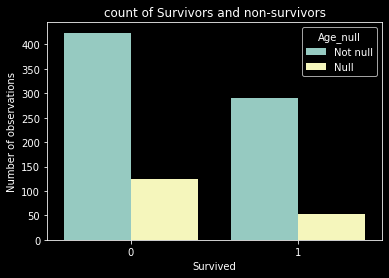

In [12]:
# let's do same for Age variable

tmp['Age_null'] = np.where(tmp['Age'].isnull(), 'Null', 'Not null')
sns.countplot(x=y_train, hue='Age_null', data=tmp)
plt.title('count of Survivors and non-survivors')
plt.ylabel('Number of observations')
plt.show()

We observe more missing data points for the people who didn't survive. The analysis therefore suggests that there was a systematic loss of data: People who didn't survive had more missing information. Presumably, the method chosen to gather the data contributes to the generation of missing data.

In [13]:
# we also have missing values for the variable Embarked

# let's have a look

x_train[x_train['Embarked'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


These two women were travelling together. Miss Icard was the maid of Mrs. Stone.

The fact that these two women survived means that they could have been asked for the information.

If these values are missing completely at random, the likelihood of data missing for these two women is the same as the likelihood of data missing for any other passanger on the Titanic. This will be hard to prove.

##### 3) Categorical Variables

In [14]:
categorical_variables

['Name', 'Sex', 'Embarked']

**Note** here I am not going to use the name column as it is, instead I will extract the identity of each person from the name and will use that to train the model.

In [15]:
# let's inspect the cardinality: number of labels within a categorical variable

for var in x_train[categorical_variables+discrete_variables+mixed_variables]:
    print("Number of categories in {}: {}".format(var, x_train[var].nunique()))

Number of categories in Name: 891
Number of categories in Sex: 2
Number of categories in Embarked: 3
Number of categories in Pclass: 3
Number of categories in SibSp: 7
Number of categories in Parch: 7
Number of categories in Cabin: 147
Number of categories in Ticket: 681


While the variable Sex contains only 2 categories and the variable Embarked contains 3 variables(low cardinality). Ticket, Name and Cabin contain a huge number of different labels.

##### 4) Distribution of Variables

Linear models assums that the variables follow the gaussian distribution. So if we want a linear model distribution of continuous variables do matter.

In [16]:
# here, I will create a function which will help identify distribution and 
# outliers at the same time

def diagnostic_plot(df, var):
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    df[var].hist(bins=50)
    plt.title('Histogram')
    
    plt.subplot(1,3,2)
    stats.probplot(df[var], dist='norm', plot=plt)
    plt.ylabel('RM quantiles')
    
    plt.subplot(1,3,3)
    sns.boxplot(y=df[var])
    plt.title('Boxplot')
    
    plt.show()

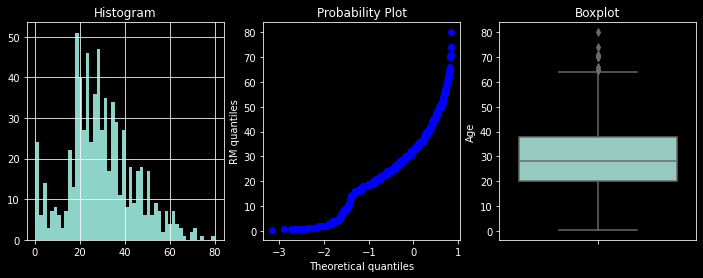

In [17]:
diagnostic_plot(x_train, 'Age')

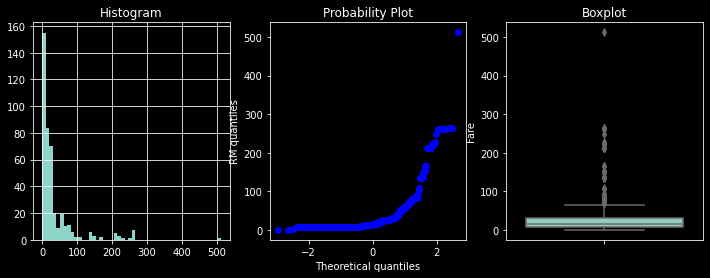

In [18]:
diagnostic_plot(x_test, 'Fare')

We can see that Age variable has somewhat Gaussian ditribution and a few outliers. Fare is highly skewed to the right and has quite a lot outliers. If the variables were normally distributed they would have been aligned to the 45 degree line in the Q-Q plot. So if we are planing to do a linear model we need to do some variable transformations.

##### 5) Feature Magnitude

In [19]:
x_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


We can see that features are in different ranges and scales.

### Feature Engineering

In this part I wiil perform feature engineering to leave the variables ready for use in machine learning model.

1) ***create new features*** (from our mixed variables)

2) ***Missing data imputation***

3) ***Rare Labels***

4) ***categorical variable Encoding***

5) ***Discretisation/ transformation***

6) ***Encoding of Numerical Variables***

7) ***Feature Scaling***

##### 1) create new features

In [20]:
# name column has different name but we can still extract some useful 
# information about the identity of passangers

x_train['Identity'] = x_train['Name'].str.split(',').str[1].str.strip().str.split(' ').str[0]
x_test['Identity'] = x_test['Name'].str.split(',').str[1].str.strip().str.split(' ').str[0]

In [21]:
x_train['Identity'].value_counts()

Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Major.         2
Col.           2
the            1
Capt.          1
Ms.            1
Sir.           1
Lady.          1
Mme.           1
Don.           1
Jonkheer.      1
Name: Identity, dtype: int64

Most of the observations contain either Mr., Miss or Mrs. For the remaining ones I will put them under the same umbrella - 'Rare' label. Which I will do later.

In [22]:
# let's drop the name column as we don't want to include it in our model

x_train.drop('Name', axis=1, inplace=True)
x_test.drop('Name', axis=1, inplace=True)

In [23]:
# engineer mixed variables
# let's extract numerical and categorical part from cabin column

x_train['cabin_num'] = x_train['Cabin'].str.extract('(\d+)') #captures numeric part
x_train['cabin_num'] = x_train['cabin_num'].astype('float')
x_train['cabin_cat'] = x_train['Cabin'].str[0]
x_train.drop('Cabin', axis=1, inplace=True)

# creating the same features in test set

x_test['cabin_num'] = x_test['Cabin'].str.extract('(\d+)')
x_test['cabin_num'] = x_test['cabin_num'].astype('float')
x_test['cabin_cat'] = x_test['Cabin'].str[0]
x_test.drop('Cabin', axis=1, inplace=True)

In [24]:
# let's extract the numerical and categorical part for ticket

# extract the last bit of ticket as number
x_train['ticket_num'] = x_train['Ticket'].apply(lambda s: s.split()[-1])
x_train['ticket_num'] = pd.to_numeric(x_train['ticket_num'],
                                       errors='coerce',
                                       downcast='integer')

# extract the first part of ticket as category
x_train['ticket_cat'] = x_train['Ticket'].apply(lambda s: s.split()[0])
x_train['ticket_cat'] = np.where(x_train['ticket_cat'].str.isdigit(),
                                  np.nan, x_train['ticket_cat'])

x_train.drop('Ticket', axis=1, inplace=True)

In [25]:
# propagating the same changes on the test set

x_test['ticket_num'] = x_test['Ticket'].apply(lambda s: s.split()[-1])
x_test['ticket_num'] = pd.to_numeric(x_test['ticket_num'],
                                      errors='coerce',
                                      downcast='integer')
x_test['ticket_cat'] = x_test['Ticket'].apply(lambda s: s.split()[0])
x_test['ticket_cat'] = np.where(x_test['ticket_cat'].str.isdigit(),
                                 np.nan, x_test['ticket_cat'])

x_test.drop('Ticket', axis=1, inplace=True)

In [26]:
# I am also going to drop the Ids from both train and test set
# as they are unique for each passanger 
x_train.drop(['PassengerId'], axis=1, inplace=True)
x_test.drop(['PassengerId'], axis=1, inplace=True)

##### 2) Missing data imputation

In [27]:
x_train.isnull().mean()

Pclass        0.000000
Sex           0.000000
Age           0.198653
SibSp         0.000000
Parch         0.000000
Fare          0.000000
Embarked      0.002245
Identity      0.000000
cabin_num     0.775533
cabin_cat     0.771044
ticket_num    0.004489
ticket_cat    0.741863
dtype: float64

In [28]:
x_test.isnull().mean()

Pclass        0.000000
Sex           0.000000
Age           0.205742
SibSp         0.000000
Parch         0.000000
Fare          0.002392
Embarked      0.000000
Identity      0.000000
cabin_num     0.787081
cabin_cat     0.782297
ticket_num    0.000000
ticket_cat    0.708134
dtype: float64

Imputation methods I will perform

**Mean value** : Age

**Missing Label** : cabin_cat, ticket_cat

**Random Smaple** : Fare, Embarked, cabin_num, ticket_num

Random sample imputation preserves the ditribution of the original variable, it variance and covariance with other variables.
For cabin_cat and ticket_cat I will use 'Missing' label. Because here I don't want to assume anything about the fact the data is missing. And I believe it is well suited when the number of missing data point is high.

In [29]:
# Let's fill na in both train and test

x_train['cabin_cat'].fillna('Missing',inplace=True)
x_test['cabin_cat'].fillna('Missing', inplace=True)

x_train['ticket_cat'].fillna('Missing', inplace=True)
x_test['ticket_cat'].fillna('Missing', inplace=True)

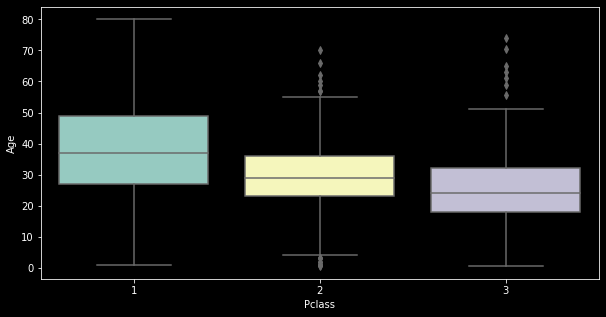

In [30]:
# If we examine the relation between Age and Pclass we could identify that
#  age does have a relation with Pclass

plt.figure(figsize=(10,5))
sns.boxplot(x=x_train['Pclass'],y=x_train['Age'], data=x_train)
plt.show()

We can see that wealthier passangers in the higher class tend to be older, which makes sense. As the age increases income increases(in most of the cases). And as the income increases, spending also increases. I will use average values per Pclass to impute the na in Age.

In [31]:
print(x_train[x_train['Pclass']==1]['Age'].mean())
print(x_train[x_train['Pclass']==2]['Age'].mean())
print(x_train[x_train['Pclass']==3]['Age'].mean())

38.233440860215055
29.87763005780347
25.14061971830986


In [32]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        
        if Pclass == 1:
            return 38
        elif Pclass == 2:
            return 29
        else:
            return 25
        
    else:
        return Age        

In [33]:
x_train['Age'] = x_train[['Age','Pclass']].apply(impute_age, axis=1)
x_test['Age'] = x_test[['Age','Pclass']].apply(impute_age, axis=1)

In [34]:
!pip install feature_engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 490.5 kB/s eta 0:00:00


In [35]:
# I will use random sampling to preserve the distribution of continuous variables

from feature_engine.imputation import RandomSampleImputer

In [36]:
random_imputer = RandomSampleImputer(variables=['Fare', 'Embarked', 'cabin_num', 'ticket_num'],
                                    random_state=29)
random_imputer.fit(x_train)

x_train = random_imputer.transform(x_train)
x_test = random_imputer.transform(x_test)

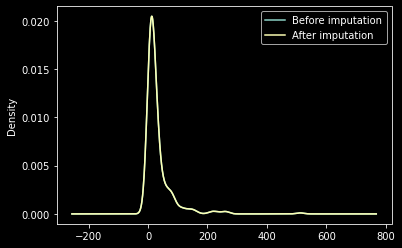

In [37]:
# let's inspect how the distribution of the variable has been affected 
# after random imputation

fig = plt.figure()
ax = fig.add_subplot(111)

# before the imputation
train_set['Fare'].plot(kind='kde', ax=ax)
# after the imputation
x_train['Fare'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Before imputation', 'After imputation']
plt.legend(lines, labels, loc='best')
plt.show()

In [38]:
# let's also inspect the variance of the variable before and after the imputation

print('Variance of Age before imputation: ', train_set['Age'].var())
print('Variance of Age after imputation: ', x_train['Age'].var())
print('Variance of Fare before imputation: ', test_set['Fare'].var())
print('Variance of Fare after imputation: ', x_test['Fare'].var())

Variance of Age before imputation:  211.01912474630802
Variance of Age after imputation:  174.55585441253987
Variance of Fare before imputation:  3125.657074319579
Variance of Fare after imputation:  3120.191727765693


We can see that the random sample imputation hasn't affected the original variance of the variable much. on the other hand variance of Age has been affected a bit.

##### 3) Rare Labels

Rare values are labels within a category that present only in a small percentage of observation. These infrequent labels are so few that it is hard to derive reliable information from them. Sometimes these infrequent labels appear only on the train set or only on the test set.

- If only on the train set, creates overfitting
- If only on the test set, our model will not know how to score them

Therefore to avoid this behavior, I will regroup them into a new category called 'Rare'.

**Note** I will treat discrete variables also as categorical variables so later I can do categorical encoding and create a monotonic relation between the variable and the target.

In [39]:
x_train['Pclass'] = x_train['Pclass'].astype('O')
x_train['SibSp'] = x_train['SibSp'].astype('O')
x_train['Parch'] = x_train['Parch'].astype('O')

x_test['Pclass'] = x_test['Pclass'].astype('O')
x_test['SibSp'] = x_test['SibSp'].astype('O')
x_test['Parch'] = x_test['Parch'].astype('O')

In [40]:
for var in x_train.columns:
    if x_train[var].dtype == 'O':
        print(x_train.groupby(var)[var].count()/ len(x_train))

Pclass
1    0.242424
2    0.206510
3    0.551066
Name: Pclass, dtype: float64
Sex
female    0.352413
male      0.647587
Name: Sex, dtype: float64
SibSp
0    0.682379
1    0.234568
2    0.031425
3    0.017957
4    0.020202
5    0.005612
8    0.007856
Name: SibSp, dtype: float64
Parch
0    0.760943
1    0.132435
2    0.089787
3    0.005612
4    0.004489
5    0.005612
6    0.001122
Name: Parch, dtype: float64
Embarked
C    0.188552
Q    0.086420
S    0.725028
Name: Embarked, dtype: float64
Identity
Capt.        0.001122
Col.         0.002245
Don.         0.001122
Dr.          0.007856
Jonkheer.    0.001122
Lady.        0.001122
Major.       0.002245
Master.      0.044893
Miss.        0.204265
Mlle.        0.002245
Mme.         0.001122
Mr.          0.580247
Mrs.         0.140292
Ms.          0.001122
Rev.         0.006734
Sir.         0.001122
the          0.001122
Name: Identity, dtype: float64
cabin_cat
A          0.016835
B          0.052750
C          0.066218
D          0.037037
E   

Here we have variables with high cardinality and low cardinality. In most of the variables there are a few labels which appear only in the few observations (< 5%). I will use the threshold of 5% meaning labels which appear in less than 5% of the observations will group them under the umbrella called 'Rare'

In [41]:
# first find frequent categories

def find_frequent(df, var, threshold):
    
    tmp = df.groupby([var])[var].count()/ len(df)
    
    frequent_labels = [var for var in tmp.loc[tmp>threshold].index.values]
    
    return frequent_labels

In [42]:
def find_rare_labels(df_train, df_test, var, tolerance):
    
    #find frequent categories
    
    frequent_labes = find_frequent(df_train, var, tolerance)
    
    #re-group rare labels
    
    df_train[var] = np.where(df_train[var].isin(frequent_labes),
                            df_train[var], 'Rare')
    
    df_test[var] = np.where(df_test[var].isin(frequent_labes),
                           df_test[var], 'Rare')
    
    return df_train, df_test

In [43]:
for var in x_train.columns:
    if x_train[var].dtype == 'O':
        x_train, x_test = find_rare_labels(x_train, x_test, var, 0.05)

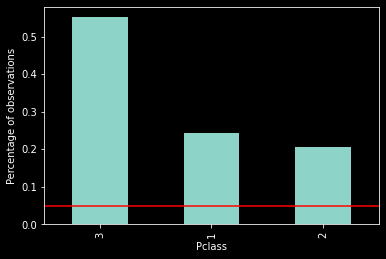

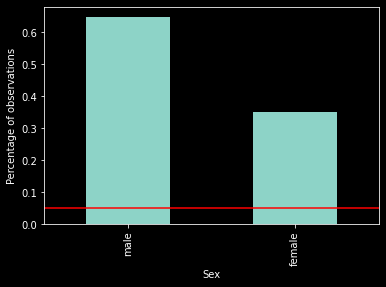

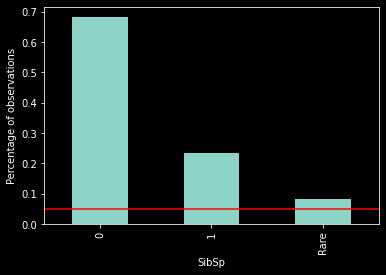

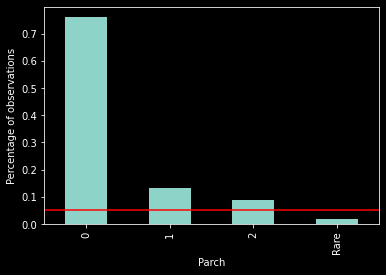

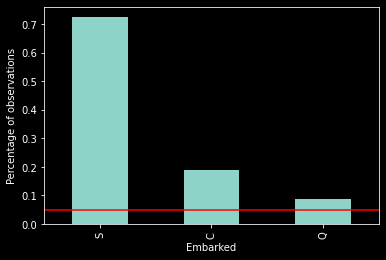

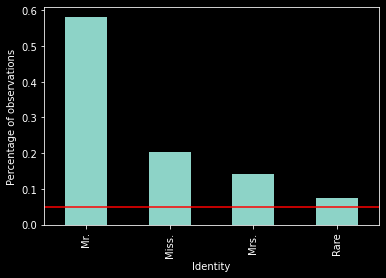

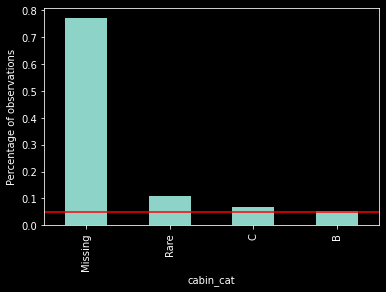

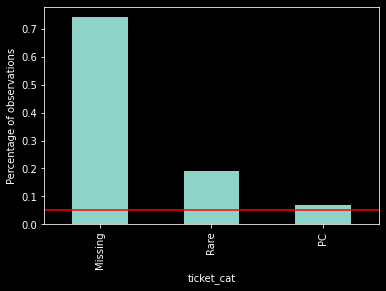

In [44]:
# let's plot the categorical variables

for var in x_train.columns:
    if x_train[var].dtype == 'O':
        tmp = pd.Series(x_train.groupby([var])[var].count() / len(x_train))
        
        # make plot with above percentage
        fig = tmp.sort_values(ascending=False).plot(kind='bar')
        fig.set_xlabel(var)
        
        # add threshold line at 5%
        fig.axhline(y=0.05, color='red')
        fig.set_ylabel('Percentage of observations')
        plt.show()

##### 4) categorical encoding

I am going to use Weight of evidence encoding because WOE creates a monotonic relationship between the target and the independent variable.

In [45]:
# for encoding using feature-engine

from feature_engine.encoding import WoEEncoder as fe_WoEEncoder

In [46]:
cat_encoder = fe_WoEEncoder(variables=['Pclass', 'Sex', 'SibSp', 'Parch','Identity', 'cabin_cat', 'ticket_cat','Embarked'])

In [47]:
cat_encoder.fit(x_train, y_train)

WoEEncoder(variables=['Pclass', 'Sex', 'SibSp', 'Parch', 'Identity',
                      'cabin_cat', 'ticket_cat', 'Embarked'])

In [48]:
x_train = cat_encoder.transform(x_train)
x_test = cat_encoder.transform(x_test)

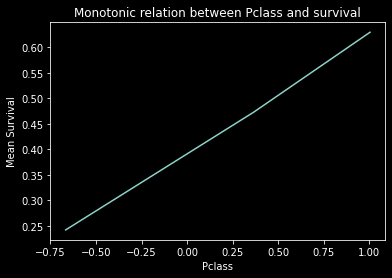

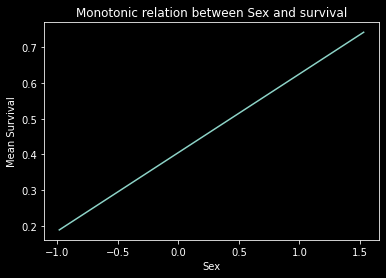

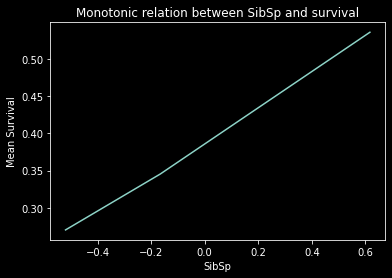

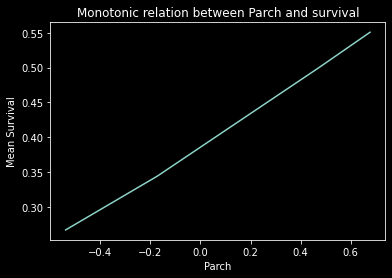

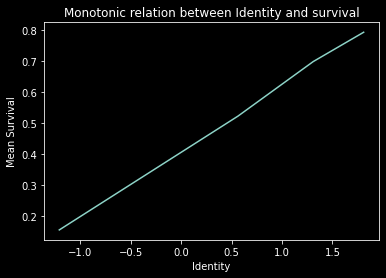

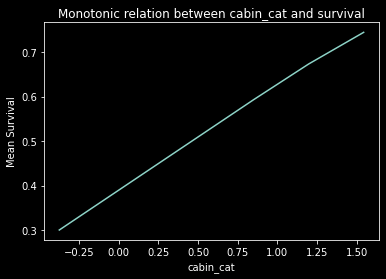

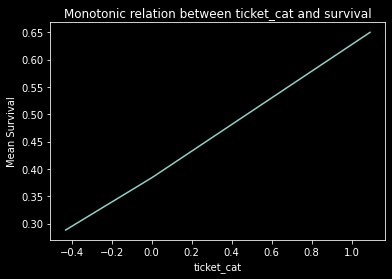

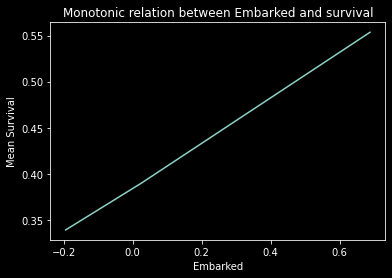

In [49]:
# let's inspect the newly created monotonic relation 
# between the newly created variables and the target

# first on the trainset
tmp_df = pd.concat([x_train,y_train], axis=1)
for var in ['Pclass', 'Sex', 'SibSp', 'Parch', 'Identity',
                      'cabin_cat', 'ticket_cat', 'Embarked']:
    fig = plt.figure()
    fig = tmp_df.groupby([var])['Survived'].mean().plot()
    fig.set_title('Monotonic relation between {} and survival'.format(var))
    fig.set_ylabel('Mean Survival')
    plt.show()

##### 5) Discretisation

Discretisation helps handle outliers and may improve value spread in skewed variables.

In [50]:
from feature_engine.discretisation import EqualFrequencyDiscretiser

In [51]:
disc = EqualFrequencyDiscretiser(variables=['cabin_num','ticket_num','Age','Fare'],
                                q = 10, return_object=True)

disc.fit(x_train)

EqualFrequencyDiscretiser(return_object=True,
                          variables=['cabin_num', 'ticket_num', 'Age', 'Fare'])

In [52]:
x_train = disc.transform(x_train)
x_test = disc.transform(x_test)

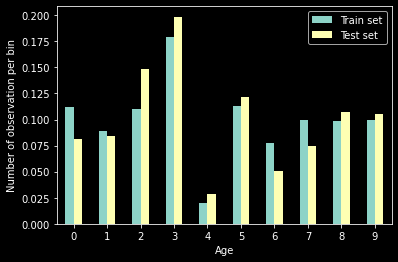

In [53]:
# and now let's explore the number of observations per bucket

t1 = x_train.groupby(['Age'])['Age'].count() / len(x_train)
t2 = x_test.groupby(['Age'])['Age'].count() / len(x_test)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['Train set', 'Test set']
tmp.plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel('Number of observation per bin')
plt.show()

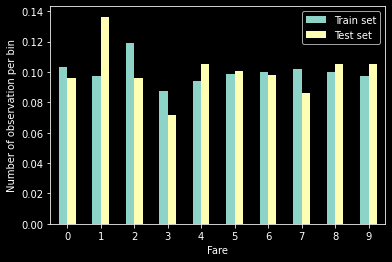

In [54]:

t1 = x_train.groupby(['Fare'])['Fare'].count() / len(x_train)
t2 = x_test.groupby(['Fare'])['Fare'].count() / len(x_test)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['Train set', 'Test set']
tmp.plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel('Number of observation per bin')
plt.show()

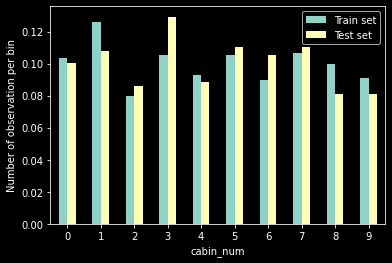

In [55]:

t1 = x_train.groupby(['cabin_num'])['cabin_num'].count() / len(x_train)
t2 = x_test.groupby(['cabin_num'])['cabin_num'].count() / len(x_test)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['Train set', 'Test set']
tmp.plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel('Number of observation per bin')
plt.show()

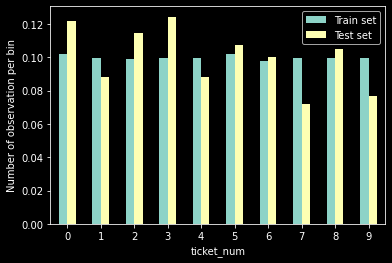

In [56]:

t1 = x_train.groupby(['ticket_num'])['ticket_num'].count() / len(x_train)
t2 = x_test.groupby(['ticket_num'])['ticket_num'].count() / len(x_test)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['Train set', 'Test set']
tmp.plot(kind='bar')
plt.xticks(rotation=0)
plt.ylabel('Number of observation per bin')
plt.show()

##### 6) Encoding of Numerical Variables

In [57]:
# I am going to use the same woe method to encode numeric variables

disc = fe_WoEEncoder(variables=['cabin_num','ticket_num','Age','Fare'])

disc.fit(x_train,y_train)

WoEEncoder(variables=['cabin_num', 'ticket_num', 'Age', 'Fare'])

In [58]:
x_train = disc.transform(x_train)
x_test = disc.transform(x_test)

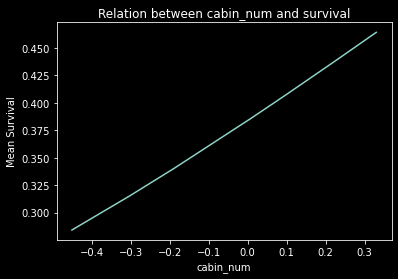

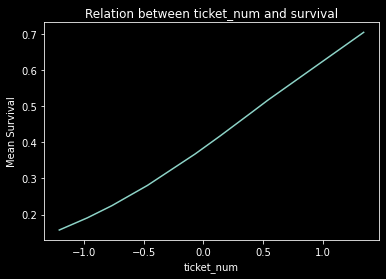

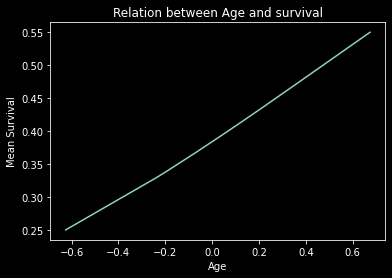

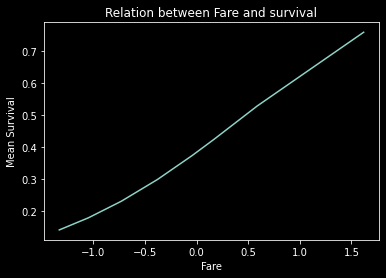

In [59]:
# let's explore the monotonic relation between the newly created variables

tmp = pd.concat([x_train,y_train], axis=1)
for var in ['cabin_num', 'ticket_num', 'Age', 'Fare']:
    fig = plt.figure()
    fig = tmp.groupby([var])['Survived'].mean().plot()
    fig.set_title('Relation between {} and survival'.format(var))
    fig.set_xlabel(var)
    fig.set_ylabel('Mean Survival')
    plt.show()

##### 7) Feature Scaling

Scale of the features is an important consideration when building machine learning model. The regression coefficients are directly affected by the scale of the variable.

I am here going to use the robust scaler because robust scaling produces more robust estimates for the center and range of the variable.

In [60]:
#  the scaler for robust scaling

from sklearn.preprocessing import RobustScaler

In [61]:
# set up the sacler
scaler = RobustScaler()

# fit the scaler to the train set so it will learn the parameters
scaler.fit(x_train)

# transform train and test set
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

### Machine Learning Model Building

In [62]:
# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV

**Logistic Regression**

In [63]:
log_reg_baseline = LogisticRegression(random_state=0)
log_reg_baseline.fit(x_train,y_train)
y_log_bs = log_reg_baseline.predict(x_test)

In [64]:
np.concatenate((y_test.values.reshape(len(y_test),1), y_log_bs.reshape(len(y_log_bs),1)),1)

array([[0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 0],
       [0, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 1],
       [1, 1],
       [1,

In [65]:
print('MSE: ',mean_squared_error(y_test,y_log_bs))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_log_bs)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_log_bs))

MSE:  0.11244019138755981


RMSE:  0.33532102735671054


Accuracy:  0.8875598086124402


In [66]:
accuries = cross_val_score(log_reg_baseline, x_train,y_train, cv=10)
print('Accuracy: {:.2f} %'.format(accuries.mean()*100))
print('Standard Deviation: {:.2f} %'.format(accuries.std()*100))

Accuracy: 82.16 %
Standard Deviation: 2.18 %


In [67]:
log_reg = LogisticRegression()
para = {"C":np.logspace(-3,3,7)}
griedsearch = GridSearchCV(estimator=log_reg,param_grid=para,scoring='accuracy',cv=10,n_jobs=-1)

griedsearch.fit(x_train,y_train)
best_accuracy = griedsearch.best_score_
best_parameters = griedsearch.best_params_
print('Best Accuracy: {:.2f}%'.format(best_accuracy*100))
print('Best Parameters:', best_parameters)

Best Accuracy: 82.16%
Best Parameters: {'C': 1.0}


In [68]:
logreg_tuned = LogisticRegression(C = 1.0, penalty = 'l2', random_state=0)
logreg_tuned.fit(x_train,y_train)
y_log_tuned = logreg_tuned.predict(x_test)

In [69]:
print('MSE: ',mean_squared_error(y_test,y_log_tuned))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_log_tuned)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_log_tuned))

MSE:  0.11244019138755981


RMSE:  0.33532102735671054


Accuracy:  0.8875598086124402


**Random Forest Classifier**

In [70]:
rc_baseline = RandomForestClassifier(criterion='entropy',random_state=0)
rc_baseline.fit(x_train,y_train)
y_rc_bs = rc_baseline.predict(x_test)

In [71]:
print('MSE: ',mean_squared_error(y_test,y_rc_bs))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_rc_bs)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_rc_bs))

MSE:  0.12440191387559808


RMSE:  0.3527065549087486


Accuracy:  0.8755980861244019


In [72]:
rc = RandomForestClassifier()
para = {'n_estimators':[75,85,95,100,105,110,115,120,125],
    'criterion':["gini", "entropy", "log_loss"],'max_depth':[2,4,6,8,10,12], 'max_features': ["sqrt", "log2"],
       'class_weight':["balanced", "balanced_subsample"]}
griedsearch = GridSearchCV(estimator=rc,param_grid=para,scoring='accuracy',cv=10,n_jobs=-1)

griedsearch.fit(x_train,y_train)
best_accuracy = griedsearch.best_score_
best_parameters = griedsearch.best_params_
print('Best Accuracy: {:.2f}%'.format(best_accuracy*100))
print('Best Parameters:', best_parameters)

/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
2160 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2160 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_forest.py", line 467, in fit
    for i, t in enumerate(trees)
  File "/opt/conda/lib/python3.7/site-packages/joblib/parallel.py", line 1043, in __call__
    if self.dispatch_one_batch(iterator):
  File "/opt/conda/lib/python3.7/site-packages/jobli

Best Accuracy: 85.52%
Best Parameters: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 8, 'max_features': 'log2', 'n_estimators': 100}


In [73]:
rc_tuned = RandomForestClassifier(n_estimators=125,class_weight='balanced',
                                 criterion = 'gini', max_depth=8, max_features='log2')
rc_tuned.fit(x_train,y_train)
y_rc_tuned = rc_tuned.predict(x_test)

In [74]:
print('MSE: ',mean_squared_error(y_test,y_rc_tuned))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_rc_tuned)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_rc_tuned))

MSE:  0.10047846889952153


RMSE:  0.3169833889962083


Accuracy:  0.8995215311004785


**SVC**

In [75]:
svc_baseline = SVC(kernel='rbf',random_state=0)

In [76]:
svc_baseline.fit(x_train,y_train)

SVC(random_state=0)

In [77]:
y_svc_bs = svc_baseline.predict(x_test)

In [78]:
accuracy_score(y_test,y_svc_bs)

0.8827751196172249

In [79]:
parameters = [{'C': [0.25,0.5,0.75,1], 'kernel':['linear']},
             {'C': [0.25,0.5,0.75,1], 'kernel':['rbf'], 'gamma':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]}]
griedsearch = GridSearchCV(estimator=svc_baseline,param_grid=parameters,scoring='accuracy',cv=10,n_jobs=-1)

griedsearch.fit(x_train,y_train)
best_accuracy = griedsearch.best_score_
best_parameters = griedsearch.best_params_
print('Best Accuracy: {:.2f}%'.format(best_accuracy*100))
print('Best Parameters:', best_parameters)

Best Accuracy: 83.84%
Best Parameters: {'C': 1, 'gamma': 0.8, 'kernel': 'rbf'}


In [80]:
svc_tuned = SVC(C=1, gamma=0.8, kernel='rbf')
svc_tuned.fit(x_train,y_train)
y_svc_tuned = svc_tuned.predict(x_test)

In [81]:
print('MSE: ',mean_squared_error(y_test,y_svc_tuned))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_svc_tuned)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_svc_tuned))

MSE:  0.14832535885167464


RMSE:  0.3851303141167605


Accuracy:  0.8516746411483254


**KNN**

In [82]:
knn_baseline = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn_baseline.fit(x_train, y_train)
y_knn_bs = knn_baseline.predict(x_test)

In [83]:
print('MSE: ',mean_squared_error(y_test,y_knn_bs))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_knn_bs)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_knn_bs))

MSE:  0.145933014354067


RMSE:  0.38201179871054636


Accuracy:  0.854066985645933


In [84]:
knn = KNeighborsClassifier()
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range, weights=['uniform', 'distance'],
                 metric=['minkowski','euclidean'])
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid.fit(x_train,y_train)
best_accuracy = grid.best_score_
best_parameters = grid.best_params_
print('Best Accuracy: {:.2f}%'.format(best_accuracy*100))
print('Best Parameters:', best_parameters)

Best Accuracy: 82.60%
Best Parameters: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}


In [85]:
knn_tuned = KNeighborsClassifier(metric='minkowski',n_neighbors=9,weights='distance')
knn_tuned.fit(x_train,y_train)
y_knn_tuned = knn_tuned.predict(x_test)

In [86]:
print('MSE: ',mean_squared_error(y_test,y_knn_tuned))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_knn_tuned)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_knn_tuned))

MSE:  0.14832535885167464


RMSE:  0.3851303141167605


Accuracy:  0.8516746411483254


**ADAboost**

In [87]:
ada_basline = AdaBoostClassifier(random_state=0)
ada_basline.fit(x_train,y_train)
y_ada_bs = ada_basline.predict(x_test)

In [88]:
print('MSE: ',mean_squared_error(y_test,y_ada_bs))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_ada_bs)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_ada_bs))

MSE:  0.10287081339712918


RMSE:  0.3207348022855162


Accuracy:  0.8971291866028708


**XGboost**

In [89]:
xg_bs = XGBClassifier(use_label_encoder=False)
xg_bs.fit(x_train,y_train)
y_xg_bs = xg_bs.predict(x_test)

In [90]:
print('MSE: ',mean_squared_error(y_test,y_xg_bs))
print('\n')
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_xg_bs)))
print('\n')
print('Accuracy: ', accuracy_score(y_test,y_xg_bs))

MSE:  0.13875598086124402


RMSE:  0.37249963873974967


Accuracy:  0.861244019138756


**submitting the result**

In [91]:
output = pd.DataFrame(data={'PassengerId':test_set['PassengerId'], 'Survived':y_rc_tuned})

In [92]:
output.to_csv('submission.csv',index=False)